# Plot of the Week 7: Latent Space Interpolation


## 1. Concept overview

A **latent variable** is a hidden coordinate used by a model to represent data compactly.

For example, an autoencoder might:
1. map an input to a latent variable `z`,
2. then **decode** `z` back into an output.

If the latent space is well-behaved, then:
- nearby latent points should decode to similar outputs,
- moving smoothly in latent space should produce smooth changes in the output.

### Why interpolate?
Suppose we have two latent values or latent vectors:
- start: `z_start`
- end: `z_end`

We can create intermediate points between them:
$$
z_t = (1-t) z_{start} + t z_{end}, \quad t \in [0,1].
$$

Then we decode each intermediate latent point and inspect the outputs.

### Main concepts:
**Latent geometry:**  
How distances and directions in latent space relate to changes in the decoded output.

**Continuity / smoothness:**  
Small changes in the latent variable should ideally produce small, gradual changes in the decoded output.

**Identifiability intuition:**  
Different latent coordinates can sometimes produce similar outputs, so latent variables are not always uniquely interpretable.


In [13]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.size"] = 11

## 2. Tutorial example: a **1D latent space**

We start with the simplest possible case: a **1D latent variable** `z`.

Instead of decoding to a realistic image, we define a small toy decoder that outputs a 1D curve.
As `z` changes, the decoder will smoothly change:
- the location of a bump
- its width
- and a small oscillation pattern

This is a useful toy example because the interpolation is easy to understand: in 1D latent space, interpolating just means moving along a line between two scalar values.


In [14]:
def toy_decoder_1d(z, n_points=300):
    """
    Decode a scalar latent z into a 1D signal y(x).
    The latent controls the center, width, and oscillation phase.
    """
    z = float(z)
    x = np.linspace(-3, 3, n_points)

    center = 1.2 * np.tanh(z)
    width = 0.45 + 0.18 * (1 + np.sin(z))
    bump = np.exp(-0.5 * ((x - center) / width) ** 2)

    ripple = 0.15 * np.sin(3.0 * x + 0.9 * z)
    y = bump + ripple

    return x, y


def linear_interpolate(z0, z1, n_steps):
    ts = np.linspace(0, 1, n_steps)
    zs = np.array([(1 - t) * np.asarray(z0) + t * np.asarray(z1) for t in ts])
    return ts, zs

## 3. Decode the 1D endpoints

We choose two scalar latent values and look at the decoded outputs first.


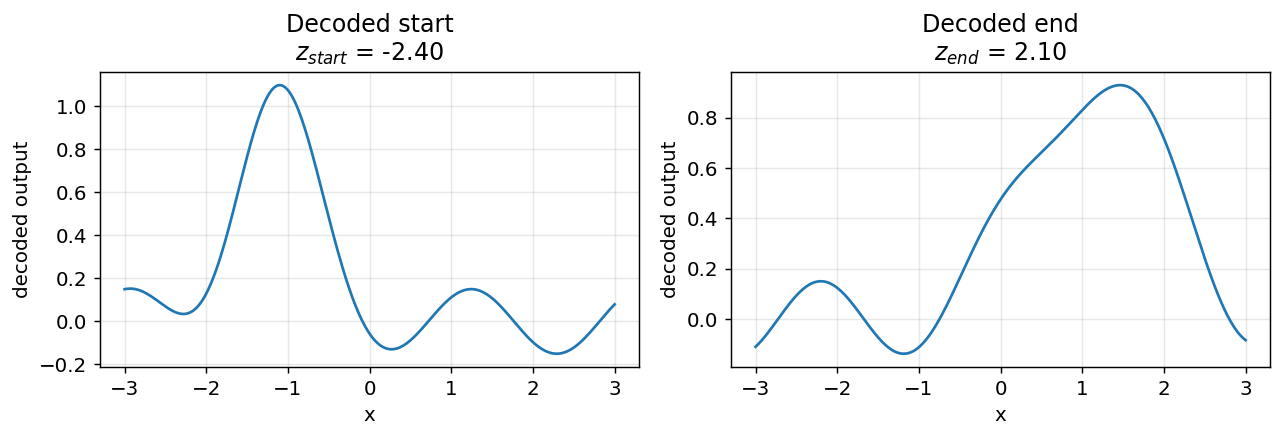

In [15]:
z_start_1d = -2.4
z_end_1d = 2.1

x, y_start = toy_decoder_1d(z_start_1d)
_, y_end = toy_decoder_1d(z_end_1d)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(x, y_start)
axes[0].set_title(f"Decoded start\n$z_{{start}}$ = {z_start_1d:.2f}")
axes[0].set_xlabel("x")
axes[0].set_ylabel("decoded output")
axes[0].grid(alpha=0.3)

axes[1].plot(x, y_end)
axes[1].set_title(f"Decoded end\n$z_{{end}}$ = {z_end_1d:.2f}")
axes[1].set_xlabel("x")
axes[1].set_ylabel("decoded output")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Interpolate in the 1D latent space

Now we create **at least five interpolation steps** between the two latent values and decode each one.

Because the latent space is 1D here, the geometry is very simple:
- each decoded curve corresponds to one point on a number line
- moving from left to right in latent space should ideally change the decoded output gradually.


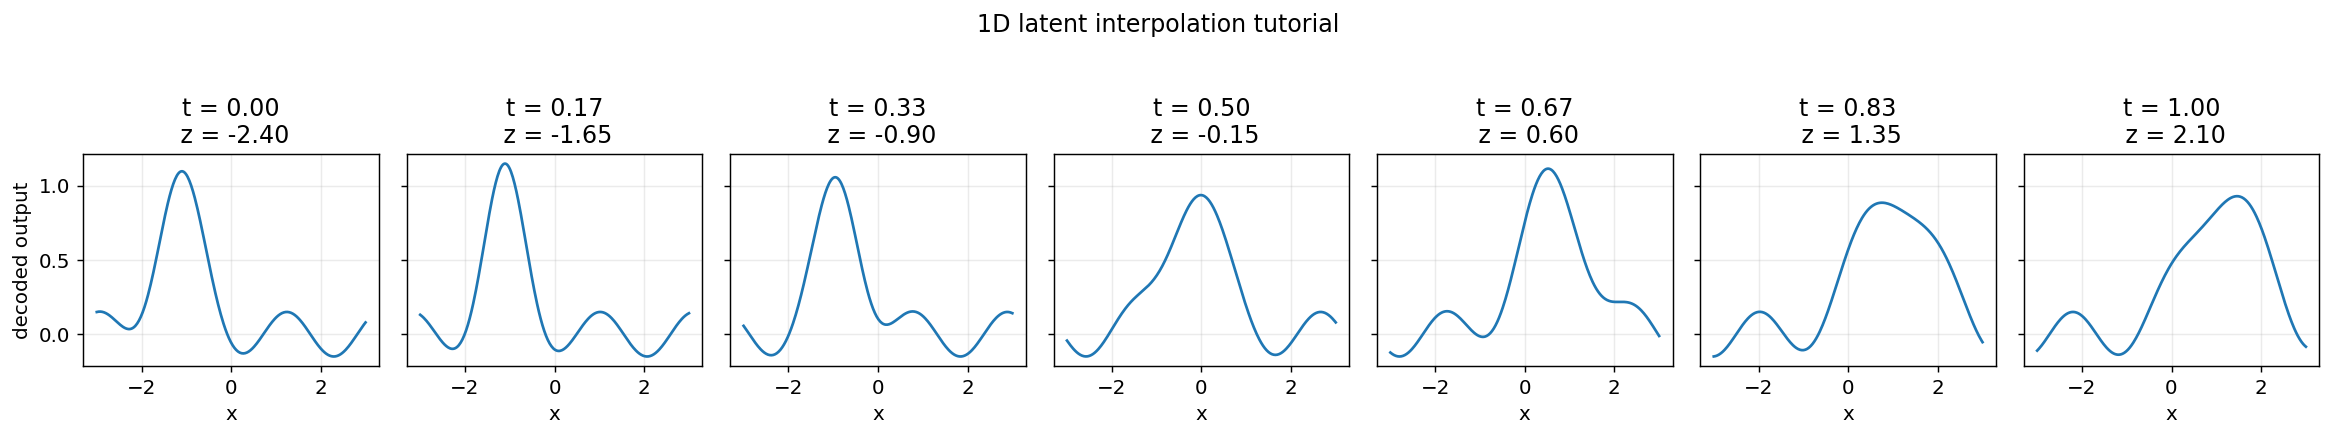

In [16]:
n_steps_1d = 7
ts_1d, z_path_1d = linear_interpolate(z_start_1d, z_end_1d, n_steps_1d)

fig, axes = plt.subplots(1, n_steps_1d, figsize=(2.6 * n_steps_1d, 3.2), sharey=True)

for ax, t, z in zip(axes, ts_1d, z_path_1d):
    x, y = toy_decoder_1d(z)
    ax.plot(x, y)
    ax.set_title(f"t = {t:.2f}\n z = {float(z):.2f}")
    ax.set_xlabel("x")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("decoded output")
fig.suptitle("1D latent interpolation tutorial", y=1.04)
plt.tight_layout()
plt.show()

## 7. [Student Section] Extend this idea to a **2D latent interpolation**

### Your task
Use a **2D latent vector** `z = [z1, z2]` and generate a latent interpolation plot with:
- **at least five interpolation steps**, and
- the **corresponding decoded outputs**.

In the code below, we provide a 2D toy decoder that maps a latent vector to a small grayscale image.

### What you should change
Edit at least one of these:
1. `z_start_student`
2. `z_end_student`
3. `n_steps_student`
4. the decoder behavior itself (optional, for extra exploration)

In [17]:
def toy_decoder_2d(z, grid_size=80):
    """
    Decode a 2D latent vector into a grayscale image.
    z[0] mainly controls horizontal position and stripe phase.
    z[1] mainly controls vertical position and width.
    """
    z = np.asarray(z).reshape(-1)
    z1, z2 = z[0], z[1]

    x = np.linspace(-1, 1, grid_size)
    y = np.linspace(-1, 1, grid_size)
    X, Y = np.meshgrid(x, y)

    cx = 0.65 * np.tanh(z1)
    cy = 0.65 * np.tanh(z2)
    sigma = 0.18 + 0.08 * (1 + np.sin(z2))

    blob = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma ** 2))
    stripes = 0.18 * np.sin(8 * X + 1.5 * z1) * np.cos(6 * Y - z2)

    img = blob + stripes
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img


z_start_student = np.array([-2.0, -1.4])
z_end_student   = np.array([ 2.1,  1.7])
n_steps_student = 6   # must be at least 5

# Interpolate in 2D latent space
ts_student, z_path_student = linear_interpolate(z_start_student, z_end_student, n_steps_student)

# Decode each latent vector using toy_decoder_2d
decoded_student = np.array([toy_decoder_2d(z) for z in z_path_student])

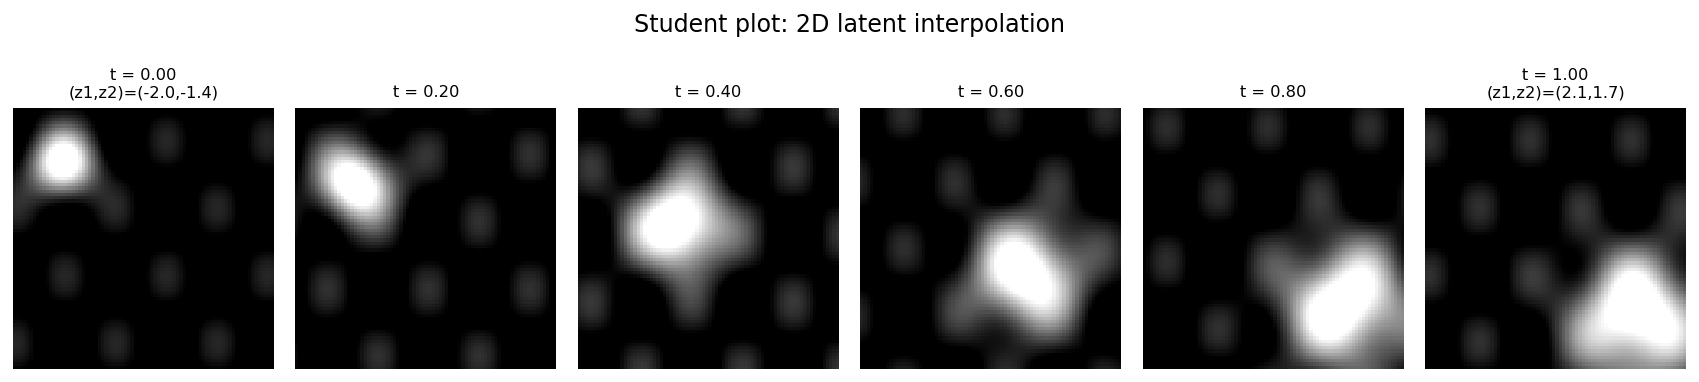

In [18]:
# Plot decoded outputs
contrast_factor = 1.6  # >1 increases visual contrast

fig, axes = plt.subplots(1, n_steps_student, figsize=(2.2 * n_steps_student, 3.0))
for i, (ax, t, z, img) in enumerate(zip(axes, ts_student, z_path_student, decoded_student)):
    # Simple contrast stretch around 0.5 to make transitions pop.
    img_vis = np.clip((img - 0.5) * contrast_factor + 0.5, 0.0, 1.0)

    ax.imshow(img_vis, cmap="gray", vmin=0.0, vmax=1.0)

    title = f"t = {t:.2f}"
    if i == 0 or i == (n_steps_student - 1):
        title += f"\n(z1,z2)=({z[0]:.1f},{z[1]:.1f})"

    ax.set_title(title, fontsize=9)
    ax.axis("off")

fig.suptitle("Student plot: 2D latent interpolation", y=1.02)
plt.tight_layout()
plt.show()